# Delhi PM2.5 Forecasting

This project uses historical Delhi PM2.5 data to compare classical
time-series forecasting models and predict future PM2.5 levels.

## 1. Problem Statement

Delhi regularly sees hazardous PM2.5 (fine particulate matter) levels,
especially in winter. The goal is to forecast future PM2.5 levels using
past observations alone, and compare a few classical time-series models:
Naive, Seasonal Naive, ARIMA, and SARIMA. Models are evaluated using
RMSE and MAE.

## 2. Load & Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('city_day.csv')
delhi = df[df['City'] == 'Delhi'][['Date', 'PM2.5']].copy()
delhi['Date'] = pd.to_datetime(delhi['Date'])
delhi = delhi.sort_values('Date').set_index('Date').asfreq('D')
delhi.head()


,PM2.5
Date,
2015-01-01,313.22
2015-01-02,186.18
2015-01-03,87.18
2015-01-04,151.84
2015-01-05,146.60


### Missing Values

There are two missing PM2.5 observations, which are filled using
time-based linear interpolation.

In [3]:
print(delhi['PM2.5'].isnull().sum(), "missing values")
pm25 = delhi['PM2.5'].interpolate(method='time')


2 missing values


The series is resampled to weekly averages so the annual seasonal cycle can be modeled with a seasonal period of 52.

In [4]:
weekly = pm25.resample('W').mean()
weekly.head()


Date
2015-01-04    184.605000
2015-01-11    196.005714
2015-01-18    187.650000
2015-01-25    156.357143
2015-02-01    162.784286
Freq: W-SUN, Name: PM2.5, dtype: float64

## 3. Train-Test Split

The last 52 weeks (one full year) are held out as the test set.

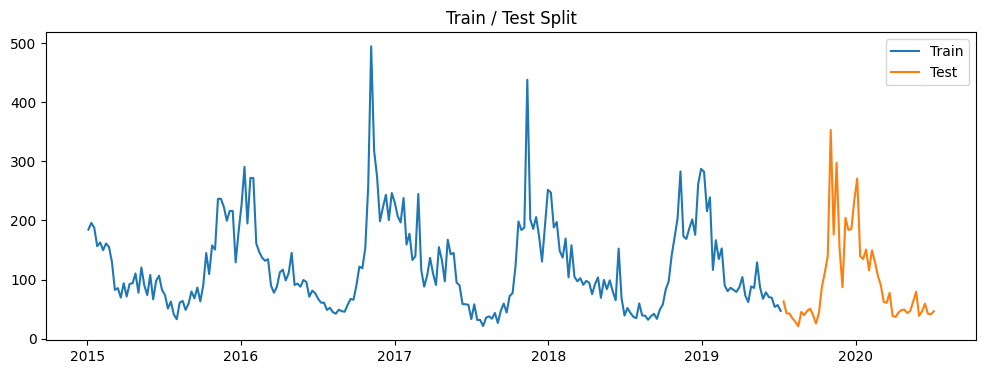

In [5]:
test_weeks = 52
train = weekly.iloc[:-test_weeks]
test = weekly.iloc[-test_weeks:]

plt.figure(figsize=(12, 4))
plt.plot(train.index, train.values, label='Train')
plt.plot(test.index, test.values, label='Test')
plt.legend()
plt.title('Train / Test Split')
plt.show()


## 4. Exploratory Data Analysis

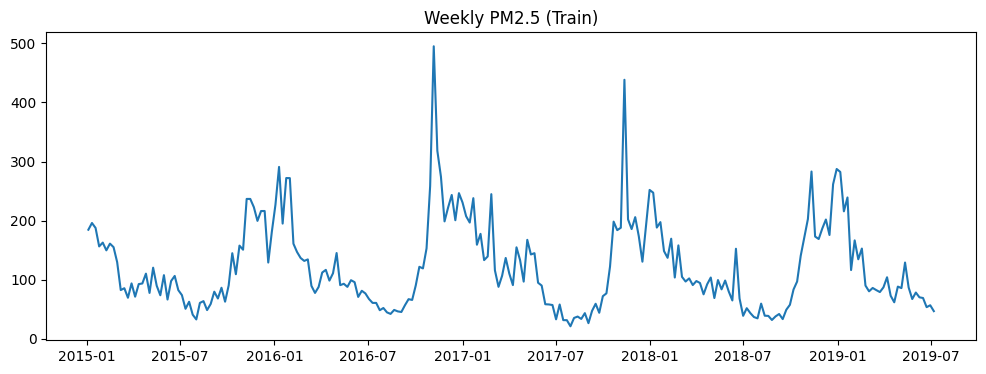

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(train.index, train.values)
plt.title('Weekly PM2.5 (Train)')
plt.show()


### Monthly Pattern

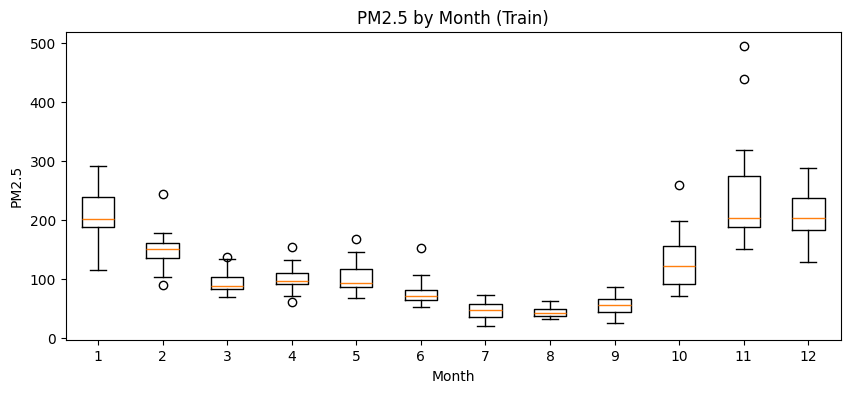

In [7]:
monthly = train.groupby(train.index.month)
data = [g.values for _, g in monthly]

plt.figure(figsize=(10, 4))
plt.boxplot(data, tick_labels=range(1, 13))
plt.xlabel('Month')
plt.ylabel('PM2.5')
plt.title('PM2.5 by Month (Train)')
plt.show()


## 5. Seasonality Analysis

In [8]:
result = adfuller(train)
print(f"ADF p-value: {result[1]:.4f}")


ADF p-value: 0.0018


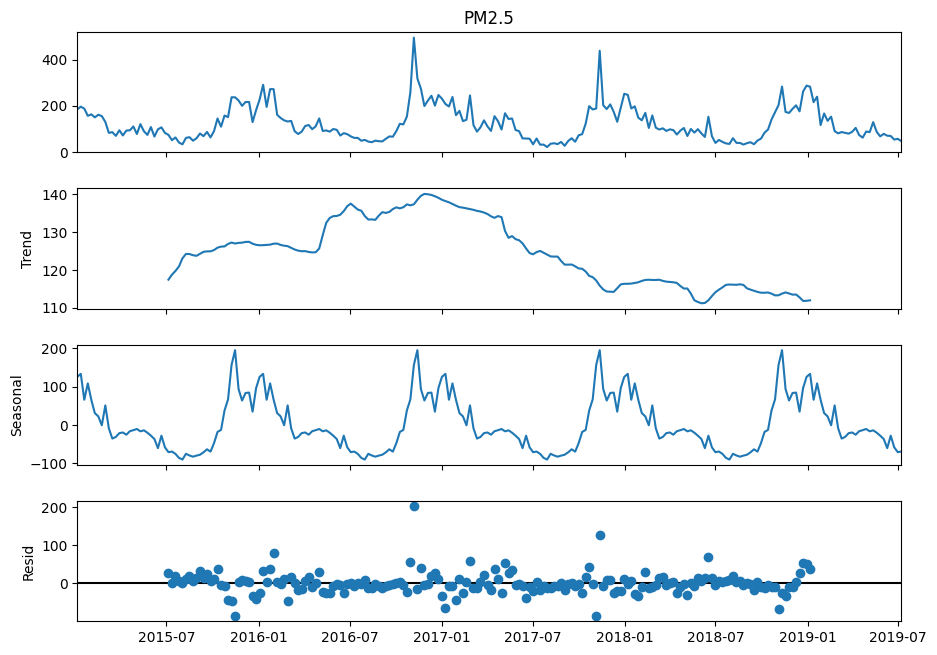

In [9]:
decomposition = seasonal_decompose(train, model='additive', period=52)
fig = decomposition.plot()
fig.set_size_inches(10, 7)
plt.show()


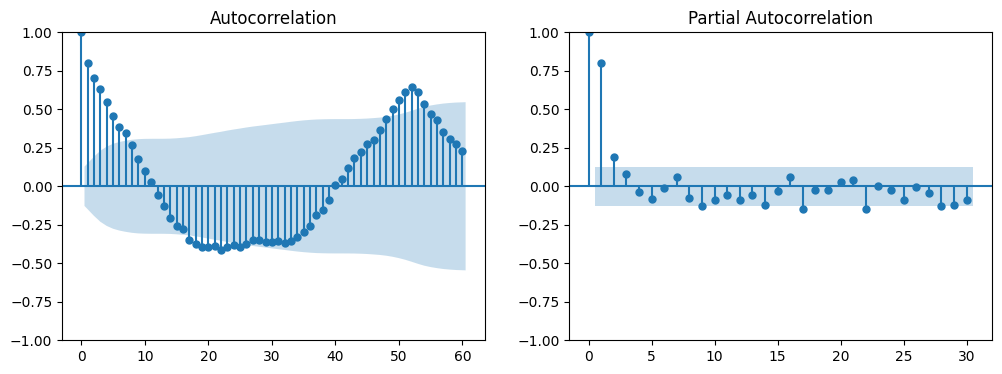

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train, lags=60, ax=axes[0])
plot_pacf(train, lags=30, ax=axes[1])
plt.show()


PACF cuts off sharply after lag 1, suggesting a low-order AR term. ACF shows a bump around lag 52, confirming annual seasonality.

## 6. Baseline Models

In [11]:
def naive_forecast(history, horizon):
    return np.repeat(history.iloc[-1], horizon)

def seasonal_naive_forecast(history, horizon, season_length=52):
    last_season = history.iloc[-season_length:]
    reps = int(np.ceil(horizon / season_length))
    return np.tile(last_season.values, reps)[:horizon]


## 7. ARIMA

In [12]:
arima_candidates = [(1, 0, 0), (2, 0, 0), (1, 0, 1), (2, 0, 1)]


## 8. SARIMA

In [13]:
sarima_candidates = [
    ((1, 0, 0), (1, 0, 0, 52)),
    ((1, 0, 0), (1, 1, 0, 52)),
    ((2, 0, 0), (1, 0, 0, 52)),
    ((1, 0, 1), (0, 1, 1, 52)),
]


## 9. Model Comparison

We compare the candidate models using time-series cross-validation and
select the model with the lowest RMSE.

In [14]:
tscv = TimeSeriesSplit(n_splits=4, test_size=13)

def evaluate(fn, series, cv):
    scores = []
    for tr_idx, val_idx in cv.split(series):
        cv_train, cv_val = series.iloc[tr_idx], series.iloc[val_idx]
        preds = fn(cv_train, len(cv_val))
        scores.append(np.sqrt(mean_squared_error(cv_val, preds)))
    return np.mean(scores)

results = {}
results['Naive'] = evaluate(lambda h, n: naive_forecast(h, n), train, tscv)
results['Seasonal Naive'] = evaluate(lambda h, n: seasonal_naive_forecast(h, n), train, tscv)

for order in arima_candidates:
    results[f'ARIMA{order}'] = evaluate(
        lambda h, n, o=order: ARIMA(h, order=o).fit().forecast(n), train, tscv)

for order, sorder in sarima_candidates:
    results[f'SARIMA{order}x{sorder}'] = evaluate(
        lambda h, n, o=order, s=sorder: SARIMAX(
            h, order=o, seasonal_order=s,
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False).forecast(n), train, tscv)

results_df = pd.Series(results).sort_values().rename('CV RMSE').to_frame()
results_df


,CV RMSE
"SARIMA(1, 0, 1)x(0, 1, 1, 52)",30.787558
Seasonal Naive,32.640315
"SARIMA(1, 0, 0)x(1, 0, 0, 52)",32.884450
"SARIMA(1, 0, 0)x(1, 1, 0, 52)",39.364648
"SARIMA(2, 0, 0)x(1, 0, 0, 52)",55.510707
"ARIMA(1, 0, 0)",68.919271
"ARIMA(2, 0, 0)",72.118096
"ARIMA(1, 0, 1)",73.747714
"ARIMA(2, 0, 1)",73.916262
Naive,87.066060


In [15]:
best_model_name = results_df.index[0]
print("Best model:", best_model_name, "-", round(results_df.iloc[0, 0], 2))


Best model: SARIMA(1, 0, 1)x(0, 1, 1, 52) - 30.79


### Fit Best Model on Training Data

In [16]:
def fit_model(name, series):
    if name == 'Naive':
        return ('naive', None)
    if name == 'Seasonal Naive':
        return ('seasonal_naive', None)
    for order, sorder in sarima_candidates:
        if name == f'SARIMA{order}x{sorder}':
            return ('sarima', SARIMAX(series, order=order, seasonal_order=sorder,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False))
    for order in arima_candidates:
        if name == f'ARIMA{order}':
            return ('arima', ARIMA(series, order=order).fit())

model_type, model = fit_model(best_model_name, train)


## 10. Final Evaluation

In [17]:
def forecast_with(model_type, model, history, horizon):
    if model_type == 'naive':
        return naive_forecast(history, horizon)
    if model_type == 'seasonal_naive':
        return seasonal_naive_forecast(history, horizon)
    return model.forecast(horizon)

preds = forecast_with(model_type, model, train, len(test))
preds = pd.Series(np.asarray(preds), index=test.index)

mae = mean_absolute_error(test, preds)
rmse = np.sqrt(mean_squared_error(test, preds))
print(f"Test MAE:  {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")


Test MAE:  34.03
Test RMSE: 47.95


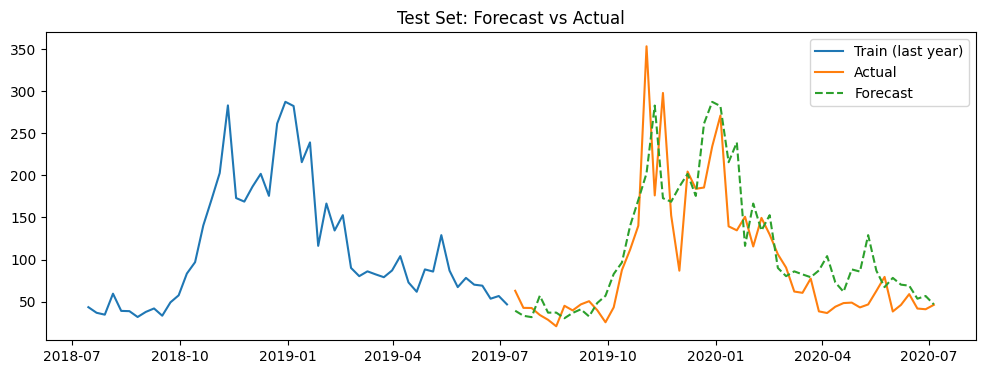

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(train.index[-52:], train.values[-52:], label='Train (last year)')
plt.plot(test.index, test.values, label='Actual')
plt.plot(preds.index, preds.values, label='Forecast', linestyle='--')
plt.legend()
plt.title('Test Set: Forecast vs Actual')
plt.show()


The test period overlaps the 2020 COVID-19 lockdown, during which PM2.5 dropped noticeably below typical levels for that time of year — part of the test error reflects this, not just model quality.

### Residual Check

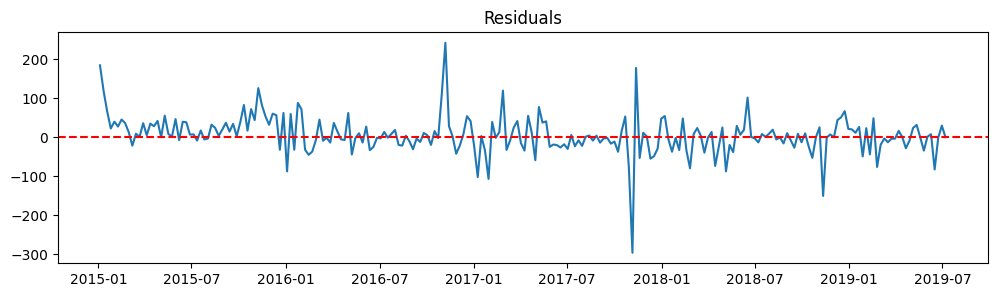

,lb_stat,lb_pvalue
10,13.877359,1.786595e-01
20,30.236482,6.611135e-02
52,126.187361,4.169003e-08


In [19]:
resid = model.resid if model is not None else train.diff(52).dropna()

plt.figure(figsize=(12, 3))
plt.plot(resid.index, resid.values)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals')
plt.show()

lb = acorr_ljungbox(resid, lags=[10, 20, 52], return_df=True)
lb


No significant autocorrelation at lags 10 and 20, but some remains at lag 52 — the seasonal term doesn't fully capture the annual pattern.

## 11. Future Forecast

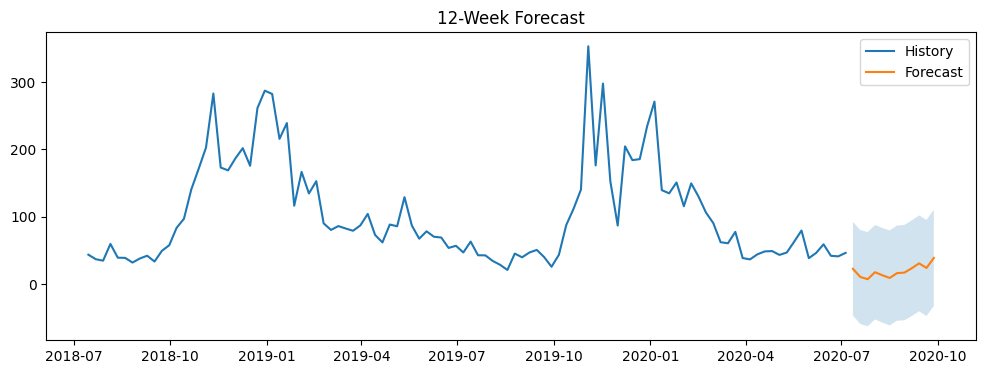

2020-07-12    22.5
2020-07-19    10.4
2020-07-26     7.1
2020-08-02    17.5
2020-08-09    12.9
2020-08-16     8.9
2020-08-23    16.1
2020-08-30    16.9
2020-09-06    23.4
2020-09-13    30.6
2020-09-20    23.7
2020-09-27    38.7
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [20]:
full_series = weekly.copy()
_, deploy_model = fit_model(best_model_name, full_series)

horizon = 12
if model_type in ('arima', 'sarima'):
    fc = deploy_model.get_forecast(steps=horizon)
    future = fc.predicted_mean
    ci = fc.conf_int(alpha=0.05)
else:
    idx = pd.date_range(full_series.index[-1] + pd.Timedelta(weeks=1), periods=horizon, freq='W')
    future = pd.Series(forecast_with(model_type, None, full_series, horizon), index=idx)
    ci = None

plt.figure(figsize=(12, 4))
plt.plot(full_series.index[-104:], full_series.values[-104:], label='History')
plt.plot(future.index, future.values, label='Forecast')
if ci is not None:
    plt.fill_between(future.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2)
plt.legend()
plt.title('12-Week Forecast')
plt.show()

future.round(1)
